<a href="https://colab.research.google.com/github/adhammkhaled/Pattern-Recognition-Labs/blob/main/Style%20Transfer/cnn_style_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 03

  Style Transfer with Multi-Input Conditioning:
In this assignment, you will implement a neural style transfer pipeline that takes two input images
and a style threshold:
- A content image, such as a photograph of a city or a person
- A style image, such as a painting by Van Gogh or Picasso
- The style threshold is a scalar value that determines the degree to which the style is
transferred onto the content image


Your model will generate a new image that preserves the content of the first image while adopting
the style of the second, modulated by the threshold value. To understand the underlying principles
of neural style transfer, you are expected to read the foundational paper on this topic https://openaccess.thecvf.com/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf

## **Part One**

In [ ]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disables GPU

import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import os
import random
from sklearn.model_selection import train_test_split
from PIL import Image
import shutil

### 1.1. Downloading

In [ ]:
# downloading WikiArt style dataset
style_path = kagglehub.dataset_download("steubk/wikiart")
print("WikiArt style images saved to:", style_path)

# downloading content image dataset
content_path = kagglehub.dataset_download("duttadebadri/image-classification")
print("Content images saved to:", content_path)

content_path = os.path.join(content_path, "images", "images")



WikiArt style images saved to: /kaggle/input/wikiart
Content images saved to: /kaggle/input/image-classification


In [ ]:
print(os.listdir(content_path))
print("\n")
print(os.listdir(style_path))

['food and d rinks', 'travel and  adventure', 'art and culture', 'architecure']


['Pop_Art', 'Minimalism', 'Color_Field_Painting', 'Mannerism_Late_Renaissance', 'Symbolism', 'Impressionism', 'Contemporary_Realism', 'High_Renaissance', 'Fauvism', 'Rococo', 'Early_Renaissance', 'Naive_Art_Primitivism', 'Pointillism', 'classes.csv', 'Cubism', 'Synthetic_Cubism', 'Action_painting', 'Abstract_Expressionism', 'New_Realism', 'wclasses.csv', 'Baroque', 'Analytical_Cubism', 'Expressionism', 'Romanticism', 'Northern_Renaissance', 'Ukiyo_e', 'Post_Impressionism', 'Art_Nouveau_Modern', 'Realism']


In [ ]:
content_image_count = 0
for root, _, files in os.walk(content_path):
    content_image_count += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"Number of content images: {content_image_count}")




Number of content images: 35093


In [ ]:
style_image_count = 0
for subfolder in os.listdir(style_path):
    subfolder_path = os.path.join(style_path, subfolder)
    if os.path.isdir(subfolder_path):
        style_image_count += len([
            f for f in os.listdir(subfolder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
print(f"Number of style images: {style_image_count}")

Number of style images: 81444


### 1.2. Splitting

In [ ]:
# 1. Collect content and style image paths
def get_image_paths(root_dir, limit=None):
    image_paths = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    random.shuffle(image_paths)  # shuffle to get diverse categories
    if limit:
        image_paths = image_paths[:limit]
    return image_paths

content_images = get_image_paths(content_path, limit=5000)
style_images = get_image_paths(style_path, limit=5000)

print(f"Selected content images: {len(content_images)}")
print(f"Selected style images: {len(style_images)}")

# 2. Split into train/val/test
def split_data(images):
    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)
    return train, val, test

content_train, content_val, content_test = split_data(content_images)
style_train, style_val, style_test = split_data(style_images)

# 3. Copy images to new folders
def copy_images(images, base_dir, label):
    for img_path in images:
        filename = os.path.basename(img_path)
        dest_dir = os.path.join(base_dir, label)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(img_path, os.path.join(dest_dir, filename))

base_output = "/content/dataset_split"

# Create folders like /content/dataset_split/content/train, etc.
for split, data in zip(
    ['train', 'val', 'test'],
    [content_train, content_val, content_test]
):
    copy_images(data, os.path.join(base_output, 'content'), split)

for split, data in zip(
    ['train', 'val', 'test'],
    [style_train, style_val, style_test]
):
    copy_images(data, os.path.join(base_output, 'style'), split)

print("Done, dataset is split and stored under /content/dataset_split")


Selected content images: 5000
Selected style images: 5000
Done, dataset is split and stored under /content/dataset_split


In [ ]:
def count_images_in_split(base_path, label):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, label, split)
        num_images = len([
            f for f in os.listdir(split_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"{label.capitalize()} - {split}: {num_images} images")

# Check content
count_images_in_split("/content/dataset_split", "content")

# Check style
count_images_in_split("/content/dataset_split", "style")


Content - train: 3486 images
Content - val: 749 images
Content - test: 748 images
Style - train: 3496 images
Style - val: 750 images
Style - test: 750 images


## **Part Two : Data Preprocessing**

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
from PIL import UnidentifiedImageError


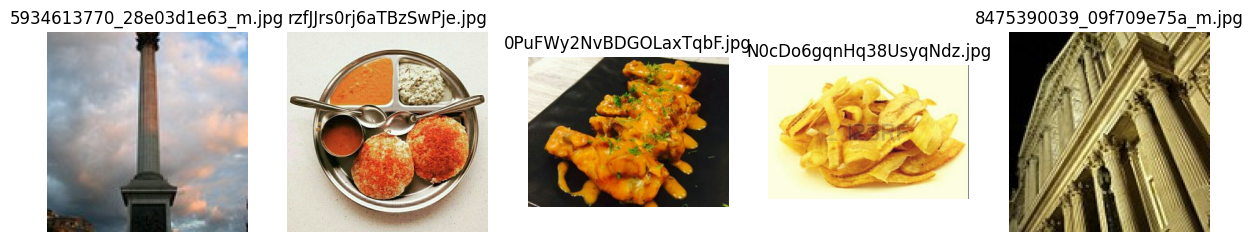

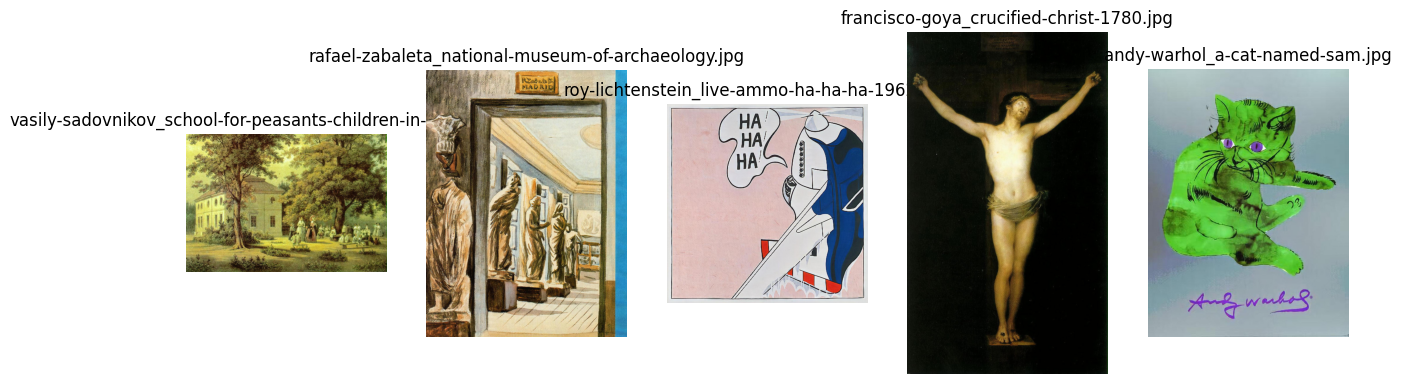

In [ ]:
# random images from the dataset split (train/val/test)
def show_images_from_split(split_dir, num_images=5):
    # all image files in the split directory
    image_files = [f for f in os.listdir(split_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    sampled_images = random.sample(image_files, num_images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i, image_name in enumerate(sampled_images):
        img = Image.open(os.path.join(split_dir, image_name))
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(image_name)

    plt.show()


content_train_dir = "/content/dataset_split/content/train"
show_images_from_split(content_train_dir, num_images=5)

print("\n\n")

style_train_dir = "/content/dataset_split/style/train"
show_images_from_split(style_train_dir, num_images=5)


### Checking Corrupted File

In [ ]:
from PIL import UnidentifiedImageError

corrupt = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        try:
            img = Image.open(os.path.join(root, file))
            img.verify()  # verifies without loading fully
        except (UnidentifiedImageError, OSError):
            corrupt.append(file)

print(f"Corrupted files: {corrupt}")


Corrupted files: []


Removing the corrupted file

In [ ]:
corrupt_file_path = "/content/dataset_split/content/train/Places365_val_00011603.jpg"

if os.path.exists(corrupt_file_path):
    os.remove(corrupt_file_path)
    print(f"Removed: {corrupt_file_path}")
else:
    print(f"File not found: {corrupt_file_path}")


File not found: /content/dataset_split/content/train/Places365_val_00011603.jpg


### Checking Images Sized

In [ ]:
sizes = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            img = Image.open(os.path.join(root, file))
            sizes.append(img.size)

from collections import Counter
print(Counter(sizes))  # Shows frequency of each image size


Counter({(256, 256): 874, (128, 128): 868, (320, 320): 390, (320, 240): 137, (100, 100): 50, (427, 240): 24, (321, 240): 22, (360, 240): 20, (1280, 720): 20, (600, 450): 14, (426, 240): 14, (240, 240): 8, (290, 356): 8, (240, 320): 8, (290, 330): 8, (290, 320): 7, (290, 360): 7, (1024, 768): 6, (450, 300): 6, (800, 533): 6, (640, 480): 6, (290, 388): 6, (290, 387): 6, (600, 400): 6, (500, 375): 5, (320, 400): 5, (800, 800): 5, (290, 377): 5, (427, 320): 5, (290, 376): 5, (1024, 683): 5, (320, 321): 5, (290, 226): 5, (759, 422): 4, (1600, 1200): 4, (300, 300): 4, (320, 427): 4, (600, 600): 4, (290, 244): 4, (1000, 600): 4, (480, 320): 4, (200, 200): 4, (475, 430): 4, (800, 448): 4, (300, 200): 4, (290, 365): 4, (500, 500): 4, (640, 400): 3, (300, 320): 3, (320, 480): 3, (213, 320): 3, (621, 414): 3, (1024, 576): 3, (361, 240): 3, (342, 240): 3, (1024, 678): 3, (900, 550): 3, (960, 720): 3, (800, 600): 3, (960, 640): 3, (660, 440): 3, (700, 400): 3, (1500, 1000): 3, (480, 319): 3, (610, 

### Checking Aspect Ratio

In [ ]:
ratios = [round(w / h, 2) for w, h in sizes]
print(Counter(ratios))  # common aspect ratios


Counter({1.0: 2247, 1.33: 223, 1.5: 145, 1.78: 83, 1.34: 34, 0.75: 34, 1.51: 26, 1.6: 23, 1.77: 22, 0.67: 21, 0.81: 20, 0.77: 16, 1.49: 13, 1.4: 13, 1.67: 13, 0.8: 12, 1.43: 12, 2.0: 11, 0.71: 10, 0.66: 9, 1.86: 9, 0.91: 9, 1.79: 9, 0.88: 9, 1.8: 8, 0.72: 8, 0.56: 8, 1.91: 8, 1.59: 8, 1.37: 8, 1.75: 8, 1.54: 8, 0.79: 8, 1.36: 7, 1.48: 7, 1.44: 7, 1.35: 7, 0.69: 6, 1.2: 6, 1.52: 6, 0.84: 6, 1.53: 6, 1.62: 6, 1.7: 6, 1.19: 6, 1.25: 6, 1.42: 6, 1.69: 6, 1.55: 6, 1.32: 6, 1.28: 6, 0.74: 5, 1.45: 5, 1.38: 5, 1.9: 5, 1.64: 5, 1.21: 5, 1.17: 5, 1.1: 5, 1.08: 5, 0.85: 5, 1.23: 4, 0.94: 4, 1.71: 4, 0.62: 4, 1.41: 4, 1.47: 4, 1.66: 4, 0.86: 4, 0.78: 4, 1.16: 4, 1.97: 4, 1.72: 4, 0.64: 4, 1.94: 4, 0.82: 4, 1.88: 4, 1.27: 4, 1.24: 4, 1.46: 3, 1.57: 3, 0.65: 3, 1.09: 3, 1.68: 3, 0.76: 3, 1.61: 3, 1.65: 3, 1.39: 3, 1.63: 3, 0.7: 3, 1.06: 3, 0.97: 3, 1.31: 3, 2.12: 3, 2.1: 3, 1.11: 3, 1.15: 3, 0.73: 3, 1.05: 3, 1.85: 3, 1.01: 3, 1.89: 3, 1.56: 3, 1.12: 2, 2.03: 2, 0.5: 2, 1.26: 2, 1.22: 2, 1.81: 2, 2

In [ ]:
formats = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        ext = os.path.splitext(file)[-1].lower()
        formats.append(ext)

print(Counter(formats))


Counter({'.jpg': 3164, '.jpeg': 211, '.png': 111})


### Checking gray scaled images

In [ ]:
grayscale_images = []

for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img = Image.open(os.path.join(root, file))
                if img.mode != 'RGB':
                    grayscale_images.append(file)
            except Exception:
                pass

print(f"Number of grayscale/non-RGB images: {len(grayscale_images)}")
print("Sample grayscale files:", grayscale_images[:5])


Number of grayscale/non-RGB images: 36
Sample grayscale files: ['212.png', '516 (3).png', 'Places365_val_00007908.jpg', 'Places365_val_00006664.jpg', '155 (3).jpg']


Exists, so will change them to rgb using PIL

In [ ]:
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img_path = os.path.join(root, file)
                img = Image.open(img_path)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(img_path)
            except Exception as e:
                print(f"Error processing {file}: {e}")


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
grayscale_images = []

for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img = Image.open(os.path.join(root, file))
                if img.mode != 'RGB':
                    grayscale_images.append(file)
            except Exception:
                pass

print(f"Number of grayscale/non-RGB images: {len(grayscale_images)}")
print("Sample grayscale files:", grayscale_images[:5])

Number of grayscale/non-RGB images: 0
Sample grayscale files: []


## Starting Preprocessing

In [ ]:
IMAGE_SIZE = (256, 256)


In [ ]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),  # to [0, 1]
    # Normalization for pretrained VGG (ImageNet stats)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225]),  # ImageNet std


])
# Inverse transform for visualization
inverse_transform = transforms.Compose([
transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                      std=[1/0.229, 1/0.224, 1/0.225]),
transforms.Lambda(lambda x: torch.clamp(x, 0, 1)),  # Clamp to [0,1]
])

In [ ]:
def create_preprocessed_sample(content_path, style_path, threshold_range=(0.3, 0.8)):
    content_img = transform(Image.open(content_path).convert("RGB"))
    style_img = transform(Image.open(style_path).convert("RGB"))
    threshold = random.uniform(*threshold_range)
    return content_img, style_img, threshold


In [ ]:
class StyleTransferDataset:
    def __init__(self, content_paths, style_paths, transform=None, threshold_range=(0.3, 0.8)):
        self.content_paths = content_paths
        self.style_paths = style_paths
        self.transform = transform
        self.threshold_range = threshold_range

    def __len__(self):
        return len(self.content_paths)

    def __getitem__(self, idx):
        content_img = Image.open(self.content_paths[idx]).convert("RGB")
        style_img = Image.open(random.choice(self.style_paths)).convert("RGB")

        # If transform is provided, apply it, otherwise just convert to numpy array
        if self.transform:
            content_tensor = self.transform(content_img)
            style_tensor = self.transform(style_img)
        else:
            content_tensor = np.array(content_img)
            style_tensor = np.array(style_img)

        threshold = random.uniform(*self.threshold_range)
        return content_img, style_img, threshold


In [ ]:
train_dataset = StyleTransferDataset(content_train, style_train, transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = StyleTransferDataset(content_val, style_val, transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)


In [ ]:
# show a batch of content + style + threshold
def visualize_batch(dataset, num_samples=5):
    for i in range(num_samples):
        content_img, style_img, threshold = dataset[i]

        # Use your existing inverse transform
        content_denorm = inverse_transform(content_img)
        style_denorm = inverse_transform(style_img)

        # Convert to displayable format
        content_np = content_denorm.permute(1, 2, 0).numpy()
        style_np = style_denorm.permute(1, 2, 0).numpy()

        # Visualization
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"Sample {i+1} | Style Threshold: {threshold:.2f}", y=1.05)

        axs[0].imshow(content_np)
        axs[0].set_title("Content", pad=10)
        axs[0].axis("off")

        axs[1].imshow(style_np)
        axs[1].set_title("Style", pad=10)
        axs[1].axis("off")

        plt.tight_layout()
        plt.show()


## **Part Three: Creating the Model**

In [ ]:
import torch
import torch.nn as nn
from torchvision import models


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# VGG Feature Extractor
class VGGFeatureExtractor(nn.Module):
    def __init__(self, selected_layers):
        super().__init__()
        self.vgg = models.vgg19(pretrained=True).features.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False
        self.selected_layers = selected_layers

    def forward(self, x):
        features = {}
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.selected_layers:
                features[i] = x
        return features



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# Style Transfer Model
class StyleTransfer:
    """Neural style transfer implementation using per-image optimization approach."""

    def __init__(self, content_layer=22, style_layers=None,
                 content_weight=8e-4, style_weight=8e-1, tv_weight=1e-6, device=device):

        if style_layers is None:
            style_layers = [1, 6, 11, 20, 29]  # Use correct integer indices

        self.content_layer = content_layer
        self.style_layers = style_layers
        self.content_weight = content_weight
        self.style_weight = style_weight
        self.tv_weight = tv_weight
        self.device = device

        # Initialize feature extractor
        all_layers = list(set([content_layer] + style_layers))
        self.feature_extractor = VGGFeatureExtractor(all_layers).to(self.device)

    def gram_matrix(self, x):
        b, c, h, w = x.size()
        features = x.view(b, c, h * w)
        gram = torch.bmm(features, features.transpose(1, 2))
        return gram / (c * h * w)

    def total_variation_loss(self, img):
        h_tv = torch.mean((img[:, :, 1:, :] - img[:, :, :-1, :]).abs())
        w_tv = torch.mean((img[:, :, :, 1:] - img[:, :, :, :-1]).abs())
        return h_tv + w_tv

    def style_loss(self, style_features, gen_features):
        loss = 0.0
        count = 0

        for layer in self.style_layers:
            if layer in style_features and layer in gen_features:
                style_gram = self.gram_matrix(style_features[layer])
                gen_gram = self.gram_matrix(gen_features[layer])
                loss += F.mse_loss(gen_gram, style_gram)
                count += 1

        if count == 0:
            return torch.tensor(0.0, device=self.device, requires_grad=True)

        return loss / count

    def content_loss(self, content_features, gen_features):
        if self.content_layer in content_features and self.content_layer in gen_features:
            return F.mse_loss(
                gen_features[self.content_layer],
                content_features[self.content_layer]
            )
        return torch.tensor(0.0, device=self.device, requires_grad=True)

    def stylize(self, content_img, style_img, num_iterations=500,
                learning_rate=0.05, init_with_content=True,
                verbose=False, alpha=None):

        content_img = content_img.to(self.device)
        style_img = style_img.to(self.device)

        with torch.no_grad():
            content_features = self.feature_extractor(content_img)
            style_features = self.feature_extractor(style_img)

        if init_with_content:
            gen_img = content_img.clone().requires_grad_(True)
        else:
            gen_img = torch.randn_like(content_img, requires_grad=True, device=self.device)

        optimizer = optim.Adam([gen_img], lr=learning_rate)

        for i in range(num_iterations):
            optimizer.zero_grad()

            gen_features = self.feature_extractor(gen_img)

            c_loss = self.content_loss(content_features, gen_features)
            s_loss = self.style_loss(style_features, gen_features)
            tv_loss = self.total_variation_loss(gen_img)

            if alpha is not None:
                total_loss = (1-alpha) * c_loss + alpha * s_loss + self.tv_weight * tv_loss
            else:
                total_loss = (self.content_weight * c_loss +
                             self.style_weight * s_loss +
                             self.tv_weight * tv_loss)

            total_loss.backward()
            optimizer.step()

            if verbose and i % 50 == 0:
                print(f"Iteration {i}/{num_iterations}, "
                      f"Loss: {total_loss.item():.4f}, "
                      f"Content: {c_loss.item():.4f}, "
                      f"Style: {s_loss.item():.4f}")

        return gen_img.detach()

    def process_batch(self, content_batch, style_batch, thresholds=None,
                     num_iterations=300, learning_rate=0.05):

        results = []

        batch_size = content_batch.size(0)
        for i in range(batch_size):
            content = content_batch[i].unsqueeze(0)
            style = style_batch[i].unsqueeze(0)
            alpha = thresholds[i].item() if thresholds is not None else None

            stylized = self.stylize(
                content, style,
                num_iterations=num_iterations,
                learning_rate=learning_rate,
                alpha=alpha,
                verbose=(i == 0)
            )

            results.append(stylized)

        return torch.cat(results, dim=0)

## **Part Four: Fine-Tuning the Model**

In [ ]:
import numpy as np
import requests
from io import BytesIO
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import vgg19

Weights and parameters for the model

In [ ]:
# Generated image size - reduced for memory efficiency
RESIZE_HEIGHT = 224

# Reduced number of iterations for faster processing
NUM_ITER = 1000

# Weights of the different loss components
CONTENT_WEIGHT = 8e-4
STYLE_WEIGHT = 6e-2

NUM_OF_PICS_SHOWN = 3
FIXED_STYLE = False

Layers names

In [ ]:
# The layer to use for the content loss.
CONTENT_LAYER_NAME = "block5_conv2"

# List of layers to use for the style loss.
STYLE_LAYER_NAMES = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]

Preproccesing and deprocessing images

In [ ]:
def preprocess_image(img, target_height, target_width):
    # Check if img is a PIL Image
    if isinstance(img, Image.Image):
        img = img.resize((target_width, target_height), Image.LANCZOS)
        arr = np.array(img)
    else:
        # If it's already a numpy array, use PIL to resize it
        try:
            # Convert numpy array to PIL Image
            pil_img = Image.fromarray(np.uint8(img))
            pil_img = pil_img.resize((target_width, target_height), Image.LANCZOS)
            arr = np.array(pil_img)
        except Exception as e:
            print(f"Error resizing image: {e}")
            # Fall back to a smaller blank image if resize fails
            arr = np.zeros((target_height, target_width, 3), dtype=np.uint8)

    arr = np.expand_dims(arr, axis=0)
    arr = vgg19.preprocess_input(arr)
    return tf.convert_to_tensor(arr)

def deprocess_image(tensor, result_height, result_width):
    tensor = tensor.numpy()
    tensor = tensor.reshape((result_height, result_width, 3))

    # Remove zero-center by mean pixel
    tensor[:, :, 0] += 103.939
    tensor[:, :, 1] += 116.779
    tensor[:, :, 2] += 123.680

    # 'BGR'->'RGB'
    tensor = tensor[:, :, ::-1]
    return np.clip(tensor, 0, 255).astype("uint8")

def load_style_image(url, transform):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert('RGB')
    return image  # Add batch dimension

Defining Model and Optimizer

In [ ]:
def get_model():
    # Build a VGG19 model loaded with pre-trained ImageNet weights
    model = vgg19.VGG19(weights='imagenet', include_top=False)

    # Get the symbolic outputs of each "key" layer (we gave them unique names).
    outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])

    # Set up a model that returns the activation values for every layer in VGG19 (as a dict).
    return keras.Model(inputs=model.inputs, outputs=outputs_dict)

def get_optimizer():
    return keras.optimizers.Adam(
        keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=8.0, decay_steps=445, decay_rate=0.98
        )
    )

Functions to get losses

In [ ]:
def compute_loss(feature_extractor, combination_image, content_features, style_features, content_weight, style_weight):
    combination_features = feature_extractor(combination_image)
    loss_content = compute_content_loss(content_features, combination_features)
    loss_style = compute_style_loss(style_features, combination_features, combination_image.shape[1] * combination_image.shape[2])

    return content_weight * loss_content + style_weight * loss_style

def compute_content_loss(content_features, combination_features):
    original_image = content_features[CONTENT_LAYER_NAME]
    generated_image = combination_features[CONTENT_LAYER_NAME]

    return tf.reduce_sum(tf.square(generated_image - original_image)) / 2

def compute_style_loss(style_features, combination_features, combination_size):
    loss_style = 0

    for layer_name in STYLE_LAYER_NAMES:
        style_feature = style_features[layer_name][0]
        combination_feature = combination_features[layer_name][0]
        loss_style += style_loss(style_feature, combination_feature, combination_size) / len(STYLE_LAYER_NAMES)

    return loss_style

def style_loss(style_features, combination_features, combination_size):
    S = gram_matrix(style_features)
    C = gram_matrix(combination_features)
    channels = style_features.shape[2]
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (combination_size ** 2))

Style Transfer Function

In [ ]:
def style_transfer(content_img, style_img, threshold, result_height=224, result_width=224, num_iterations=500):
    try:
        # Preprocess images
        content_tensor = preprocess_image(content_img, result_height, result_width)
        style_tensor = preprocess_image(style_img, result_height, result_width)

        # Start with random noise
        generated_image = tf.Variable(tf.random.uniform(content_tensor.shape, dtype=tf.dtypes.float32))

        # Build model
        model = get_model()
        optimizer = get_optimizer()

        # Calculate content and style weights based on threshold
        content_weight = CONTENT_WEIGHT * (1 - threshold)
        style_weight = STYLE_WEIGHT * threshold

        content_features = model(content_tensor)
        style_features = model(style_tensor)

        # Initialize variables to track best result
        best_loss = float('inf')
        best_image = None

        # Optimize result image
        for iter in range(num_iterations):
            with tf.GradientTape() as tape:
                loss = compute_loss(model, generated_image, content_features, style_features,
                                 content_weight, style_weight)

            # Check if current result is the best so far
            if loss < best_loss:
                best_loss = loss.numpy()
                best_image = generated_image.numpy().copy()  # Save a copy of the best image
                #print(f"New best loss at iteration {iter}: {best_loss:.2f}")

            grads = tape.gradient(loss, generated_image)

            if iter % 100 == 0:
                print(f"Sample iteration: {iter}, current loss: {loss:.2f}, best loss: {best_loss:.2f}")

            optimizer.apply_gradients([(grads, generated_image)])

        print(f"Final loss: {loss:.2f}, Best loss achieved: {best_loss:.2f}")

        # Return the image with the lowest loss
        return deprocess_image(tf.convert_to_tensor(best_image), result_height, result_width)

    except Exception as e:
        print(f"Error in style transfer: {e}")
        return np.zeros((result_height, result_width, 3), dtype=np.uint8)

Gram matrix function

In [ ]:
def gram_matrix(x):
   x = tf.transpose(x, (2, 0, 1))
   features = tf.reshape(x, (tf.shape(x)[0], -1))
   gram = tf.matmul(features, tf.transpose(features))
   return gram

Link for fixed style (if needed)

In [ ]:
style_url = "https://cdn.britannica.com/78/43678-050-F4DC8D93/Starry-Night-canvas-Vincent-van-Gogh-New-1889.jpg"
fixed_style_img = load_style_image(style_url, transform)

NameError: name 'transform' is not defined

Creating the dataset

In [ ]:

dataset = StyleTransferDataset(content_images, style_images, transform)

NameError: name 'StyleTransferDataset' is not defined

Running the model and plotting the result

Processing example 1 - Image size: 224x224, Threshold: 0.53


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_330']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Sample iteration: 0, current loss: 191655.66, best loss: 191655.66
Sample iteration: 100, current loss: 9530.10, best loss: 9530.10
Sample iteration: 200, current loss: 7766.99, best loss: 7601.39
Sample iteration: 300, current loss: 7105.01, best loss: 6885.40
Sample iteration: 400, current loss: 6742.86, best loss: 6491.99
Sample iteration: 500, current loss: 6144.99, best loss: 6134.51
Sample iteration: 600, current loss: 6395.21, best loss: 5868.70
Sample iteration: 700, current loss: 5862.10, best loss: 5757.65
Sample iteration: 800, current loss: 5822.99, best loss: 5634.67
Sample iteration: 900, current loss: 5586.05, best loss: 5500.32
Final loss: 5765.31, Best loss achieved: 5402.57
Processing example 2 - Image size: 224x224, Threshold: 0.51


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_352']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Sample iteration: 0, current loss: 88515.89, best loss: 88515.89
Sample iteration: 100, current loss: 4320.53, best loss: 4185.19
Sample iteration: 200, current loss: 3459.52, best loss: 3189.19
Sample iteration: 300, current loss: 3304.59, best loss: 2939.36
Sample iteration: 400, current loss: 2730.29, best loss: 2545.98
Sample iteration: 500, current loss: 3521.69, best loss: 2545.98
Sample iteration: 600, current loss: 2168.72, best loss: 2168.72
Sample iteration: 700, current loss: 2249.25, best loss: 2057.20
Sample iteration: 800, current loss: 5314.50, best loss: 2057.20
Sample iteration: 900, current loss: 2401.67, best loss: 2057.20
Final loss: 2337.74, Best loss achieved: 1995.37
Processing example 3 - Image size: 224x224, Threshold: 0.45


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_374']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Sample iteration: 0, current loss: 135137.00, best loss: 135137.00
Sample iteration: 100, current loss: 6334.00, best loss: 6315.52
Sample iteration: 200, current loss: 4705.57, best loss: 4705.57
Sample iteration: 300, current loss: 4399.26, best loss: 4223.76
Sample iteration: 400, current loss: 4090.14, best loss: 3880.05
Sample iteration: 500, current loss: 3780.43, best loss: 3710.81
Sample iteration: 600, current loss: 3877.79, best loss: 3520.55
Sample iteration: 700, current loss: 3244.99, best loss: 3244.99
Sample iteration: 800, current loss: 3499.79, best loss: 3243.93
Sample iteration: 900, current loss: 3522.46, best loss: 3243.93
Final loss: 3281.89, Best loss achieved: 3233.42


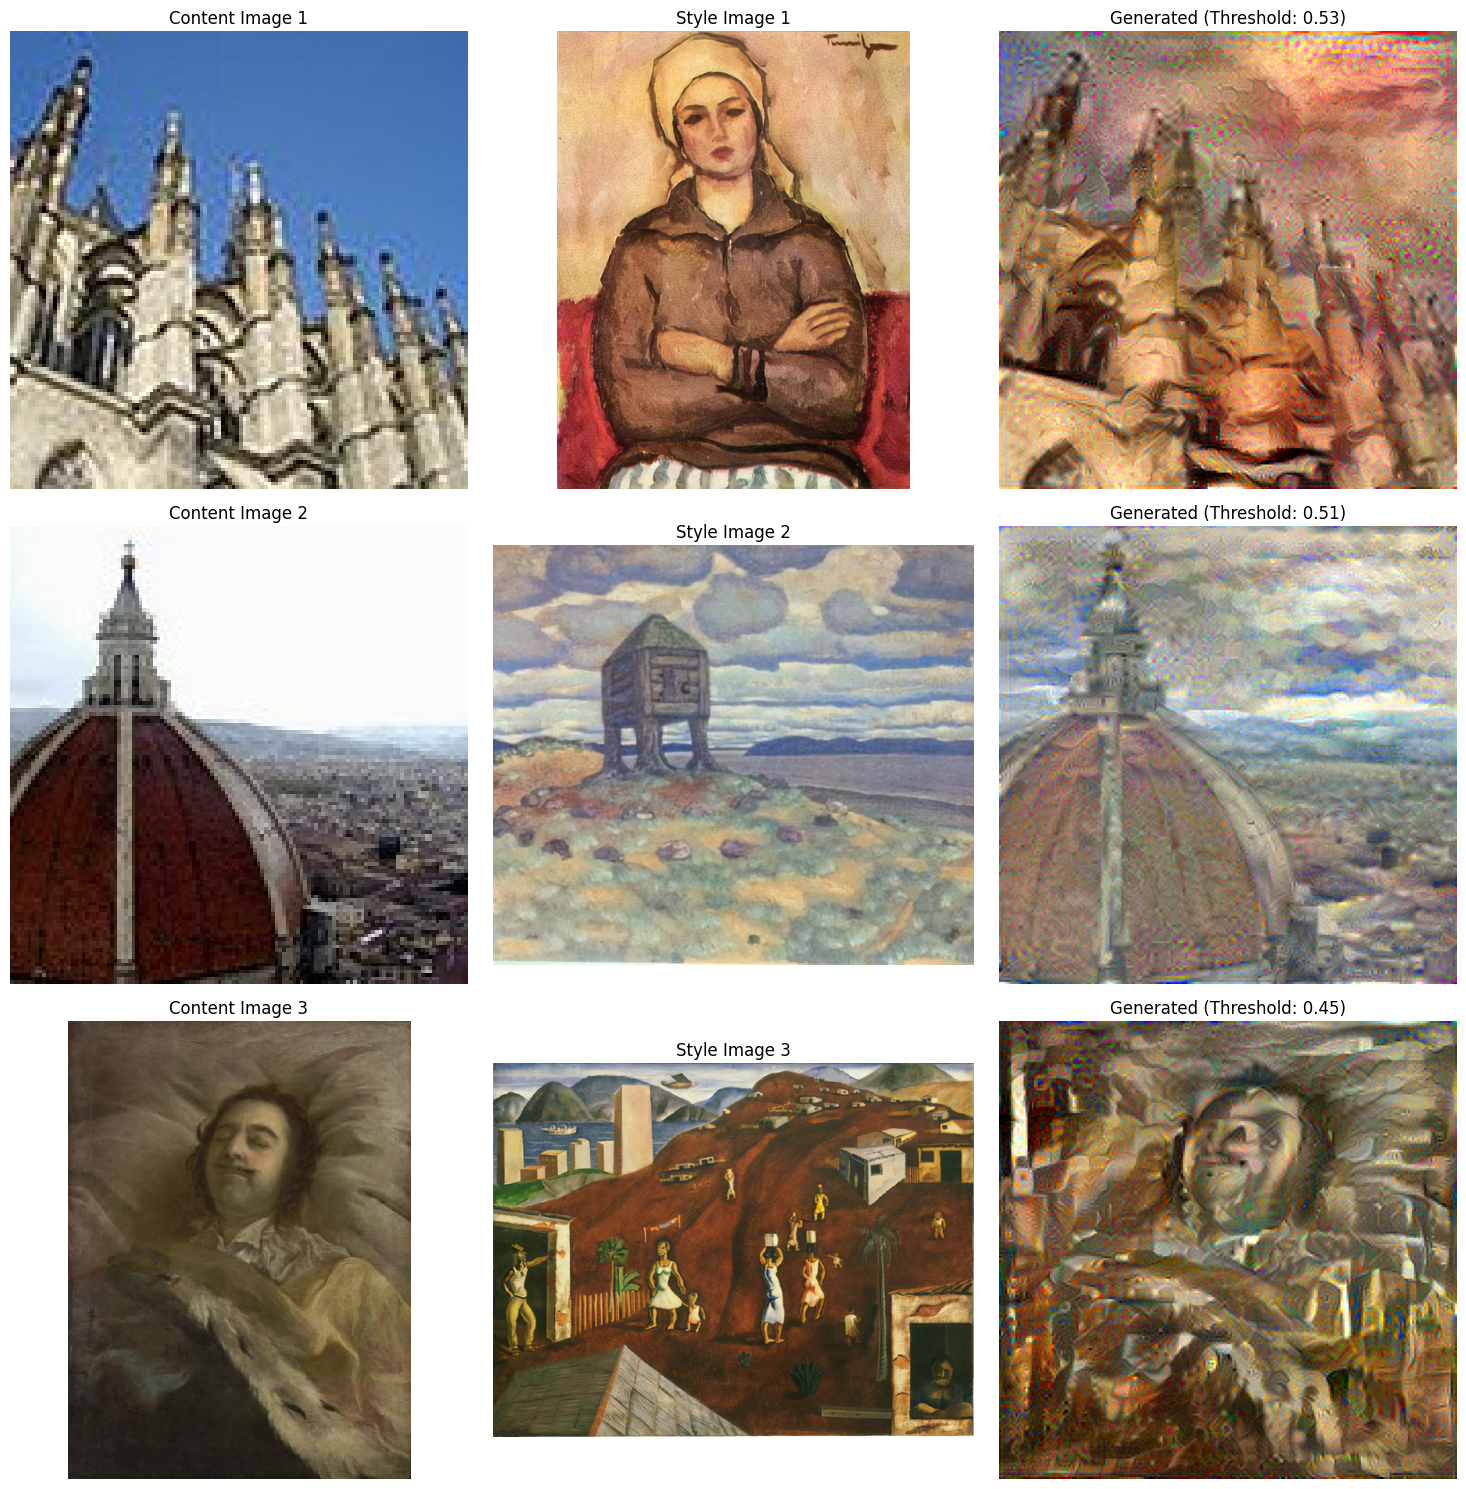

In [ ]:
# Create a figure with rows and columns based on NUM_OF_PICS_SHOWN
fig, axs = plt.subplots(NUM_OF_PICS_SHOWN, 3, figsize=(15, 5*NUM_OF_PICS_SHOWN))  # 3 columns for content, style, result

if NUM_OF_PICS_SHOWN == 1:
    axs = np.array([axs])

for idx in range(NUM_OF_PICS_SHOWN):
    try:
        # Generate random index within range
        i = random.randint(0, len(dataset) - 1)

        # Get images based on FIXED_STYLE setting
        if FIXED_STYLE:
            content_img, _, threshold = dataset[i]
            style_img = fixed_style_img
        else:
            content_img, style_img, threshold = dataset[i]

        # Pre-resize images to a manageable size to avoid OOM
        if isinstance(content_img, Image.Image):
            content_img.thumbnail((512, 512), Image.LANCZOS)
            width, height = content_img.size
        else:
            height, width = content_img.shape[:2]
            if max(height, width) > 512:
                scale = 512 / max(height, width)
                new_h, new_w = int(height * scale), int(width * scale)
                pil_img = Image.fromarray(np.uint8(content_img))
                pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
                content_img = np.array(pil_img)
                height, width = content_img.shape[:2]

        if isinstance(style_img, Image.Image):
            style_img.thumbnail((512, 512), Image.LANCZOS)
        else:
            height_s, width_s = style_img.shape[:2]
            if max(height_s, width_s) > 512:
                scale = 512 / max(height_s, width_s)
                new_h, new_w = int(height_s * scale), int(width_s * scale)
                pil_img = Image.fromarray(np.uint8(style_img))
                pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
                style_img = np.array(pil_img)

        # For the style transfer, use fixed dimensions
        new_height = RESIZE_HEIGHT
        new_width = RESIZE_HEIGHT  # Using same width as height for square output

        print(f"Processing example {idx+1} - Image size: {new_width}x{new_height}, Threshold: {threshold:.2f}")

        # Perform style transfer
        generated_result = style_transfer(
            content_img,
            style_img,
            threshold,
            result_height=new_height,
            result_width=new_width,
            num_iterations=NUM_ITER
        )

        # Convert images for display
        if isinstance(content_img, Image.Image):
            content_np = np.array(content_img)
        else:
            content_np = content_img

        if isinstance(style_img, Image.Image):
            style_np = np.array(style_img)
        else:
            style_np = style_img

        # Plot the images
        axs[idx, 0].imshow(content_np)
        axs[idx, 0].set_title(f"Content Image {idx+1}")
        axs[idx, 0].axis('off')

        axs[idx, 1].imshow(style_np)
        axs[idx, 1].set_title(f"Style Image {idx+1}")
        axs[idx, 1].axis('off')

        axs[idx, 2].imshow(generated_result)
        axs[idx, 2].set_title(f"Generated (Threshold: {threshold:.2f})")
        axs[idx, 2].axis('off')

    except Exception as e:
        print(f"Error processing example {idx}: {e}")
        # In case of error, display empty plots with error message
        for j in range(3):
            axs[idx, j].text(0.5, 0.5, 'Processing failed',
                           ha='center', va='center')
            axs[idx, j].axis('off')
        continue

plt.tight_layout()
plt.show()

In [ ]:
!pip install flask pyngrok pillow


In [ ]:
!ps aux | grep ngrok


root       13669  0.0  0.0   7376  3432 ?        S    05:13   0:00 /bin/bash -c ps aux | grep ngrok
root       13671  0.0  0.0   6484  2244 ?        S    05:13   0:00 grep ngrok


In [ ]:
!kill 9045


In [ ]:
from pyngrok import ngrok

# Paste your actual authtoken here as a string
ngrok.set_auth_token("2x7MqZHFAEUQCuH7hhUcB2aAVFP_86dHXaa2GQbt797BL6BhM")


In [ ]:
public_url = ngrok.connect(5000)
print(f" * ngrok tunnel running on {public_url}")


 * ngrok tunnel running on NgrokTunnel: "https://0995-34-125-130-10.ngrok-free.app" -> "http://localhost:5000"


In [ ]:
from PIL import Image
import numpy as np

def stylize_image(content_img, style_img, threshold=1.0,
                  output_size=512, num_iterations=1000):

    # Resize content image
    if isinstance(content_img, Image.Image):
        content_img = content_img.copy()
        content_img.thumbnail((output_size, output_size), Image.LANCZOS)
    else:
        h, w = content_img.shape[:2]
        if max(h, w) > output_size:
            scale = output_size / max(h, w)
            new_h, new_w = int(h * scale), int(w * scale)
            pil_img = Image.fromarray(np.uint8(content_img))
            pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
            content_img = np.array(pil_img)

    # Resize style image
    if isinstance(style_img, Image.Image):
        style_img = style_img.copy()
        style_img.thumbnail((output_size, output_size), Image.LANCZOS)
    else:
        h, w = style_img.shape[:2]
        if max(h, w) > output_size:
            scale = output_size / max(h, w)
            new_h, new_w = int(h * scale), int(w * scale)
            pil_img = Image.fromarray(np.uint8(style_img))
            pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
            style_img = np.array(pil_img)

    # Call the core style transfer function
    result_np = style_transfer(
        content_img,
        style_img,
        threshold,
        result_height=output_size,
        result_width=output_size,
        num_iterations=num_iterations
    )

    # Clip and convert to PIL image
    result_np = np.clip(result_np, 0, 255)
    result_img = Image.fromarray(np.uint8(result_np))
    return result_img


In [ ]:
from flask import Flask, request, render_template_string, send_file
from pyngrok import ngrok
from io import BytesIO
from PIL import Image
import numpy as np

# Flask app setup
app = Flask(__name__)

# Basic HTML template with inline CSS for styling
HTML_PAGE = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8" />
<title>Neural Style Transfer</title>
<style>
  body { font-family: Arial, sans-serif; background: #f0f0f0; text-align: center; padding: 2em; }
  h1 { color: #333; }
  form { background: white; padding: 1em; border-radius: 8px; display: inline-block; }
  input[type="file"] { margin: 1em 0; }
  input[type="submit"] { background-color: #4CAF50; color: white; padding: 0.5em 1em; border: none; border-radius: 4px; cursor: pointer; }
  input[type="submit"]:hover { background-color: #45a049; }
  img { margin-top: 1em; max-width: 90vw; border: 1px solid #ddd; border-radius: 8px; }
</style>
</head>
<body>
<h1>Neural Style Transfer</h1>
<form method="POST" enctype="multipart/form-data">
  <label>Content Image:</label><br/>
  <input type="file" name="content_img" required/><br/>
  <label>Style Image:</label><br/>
  <input type="file" name="style_img" required/><br/>
  <label>Style Intensity (0.0 to 1.0):</label><br/>
  <input type="number" name="threshold" step="0.1" min="0" max="1" value="1.0"/><br/><br/>
  <input type="submit" value="Stylize"/>
</form>
{% if stylized_url %}
  <h2>Stylized Output:</h2>
  <img src="{{ stylized_url }}" alt="Stylized Image"/>
{% endif %}
</body>
</html>
"""

# In-memory storage for the generated image
generated_images = {}

@app.route('/', methods=['GET', 'POST'])
def index():
    stylized_url = None
    if request.method == 'POST':
        content_file = request.files.get('content_img')
        style_file = request.files.get('style_img')
        threshold = float(request.form.get('threshold', 1.0))

        if content_file and style_file:
            content_img = Image.open(content_file.stream).convert('RGB')
            style_img = Image.open(style_file.stream).convert('RGB')

            # Call your stylize_image function
            output_img = stylize_image(content_img, style_img, threshold=threshold)

            # Save image in memory buffer
            buf = BytesIO()
            output_img.save(buf, format='PNG')
            buf.seek(0)

            # Store in dict to serve at a route (simple caching)
            img_id = 'output.png'
            generated_images[img_id] = buf

            stylized_url = f'/image/{img_id}'

    return render_template_string(HTML_PAGE, stylized_url=stylized_url)

@app.route('/image/<img_id>')
def serve_image(img_id):
    buf = generated_images.get(img_id)
    if buf:
        buf.seek(0)
        return send_file(buf, mimetype='image/png')
    else:
        return "Image not found", 404

# Open ngrok tunnel on port 5000
public_url = ngrok.connect(5000)
print(f" * ngrok tunnel running on {public_url}")

# Run Flask app
app.run()


 * ngrok tunnel running on NgrokTunnel: "https://1e5a-34-125-130-10.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [15/May/2025 07:59:51] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/May/2025 07:59:52] "GET /favicon.ico HTTP/1.1" 404 -


Sample iteration: 0, current loss: 280914.44, best loss: 280914.44
Sample iteration: 100, current loss: 22328.47, best loss: 22328.47
Sample iteration: 200, current loss: 16790.16, best loss: 16051.29
Sample iteration: 300, current loss: 13302.02, best loss: 12919.99
Sample iteration: 400, current loss: 11698.25, best loss: 11556.41
Sample iteration: 500, current loss: 12005.69, best loss: 10717.91
Sample iteration: 600, current loss: 11001.06, best loss: 10213.76
Sample iteration: 700, current loss: 9855.02, best loss: 9799.89
Sample iteration: 800, current loss: 10925.86, best loss: 9203.11
Sample iteration: 900, current loss: 10076.40, best loss: 8568.84


INFO:werkzeug:127.0.0.1 - - [15/May/2025 08:02:55] "POST / HTTP/1.1" 200 -


Final loss: 12737.74, Best loss achieved: 8568.84


...

INFO:werkzeug:127.0.0.1 - - [15/May/2025 08:06:19] "GET /image/output.png HTTP/1.1" 200 -


Sample iteration: 0, current loss: 176895.98, best loss: 176895.98
Sample iteration: 100, current loss: 14584.51, best loss: 14370.37
Sample iteration: 200, current loss: 9672.38, best loss: 9672.38
Sample iteration: 300, current loss: 8950.11, best loss: 8597.22
Sample iteration: 400, current loss: 8402.90, best loss: 8007.19
Sample iteration: 500, current loss: 8407.62, best loss: 7406.70
Sample iteration: 600, current loss: 7614.71, best loss: 7364.71
Sample iteration: 700, current loss: 7592.53, best loss: 6758.39
Sample iteration: 800, current loss: 7244.03, best loss: 6758.39
Sample iteration: 900, current loss: 7107.35, best loss: 6758.39


INFO:werkzeug:127.0.0.1 - - [15/May/2025 08:09:36] "POST / HTTP/1.1" 200 -


Final loss: 6974.69, Best loss achieved: 6758.39


INFO:werkzeug:127.0.0.1 - - [15/May/2025 08:09:37] "GET /image/output.png HTTP/1.1" 200 -


Upload Content Image


Saving content1.jpeg to content1 (1).jpeg
Loaded image: content1 (1).jpeg with size (284, 177)
Upload Style Image


Saving style1.jpeg to style1 (1).jpeg
Loaded image: style1 (1).jpeg with size (120, 120)
Processing image - Size: 224x224, Threshold: 0.40


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_22']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Sample iteration: 0, current loss: 216546.73, best loss: 216546.73
Sample iteration: 100, current loss: 7747.94, best loss: 7595.09
Sample iteration: 200, current loss: 6153.23, best loss: 6021.82
Sample iteration: 300, current loss: 5659.14, best loss: 5546.98
Sample iteration: 400, current loss: 5144.60, best loss: 4903.30
Sample iteration: 500, current loss: 5078.03, best loss: 4836.54
Sample iteration: 600, current loss: 4501.67, best loss: 4344.57
Sample iteration: 700, current loss: 4301.10, best loss: 4114.61
Sample iteration: 800, current loss: 6612.46, best loss: 4114.61
Sample iteration: 900, current loss: 3771.79, best loss: 3760.89
Final loss: 3887.66, Best loss achieved: 3673.37


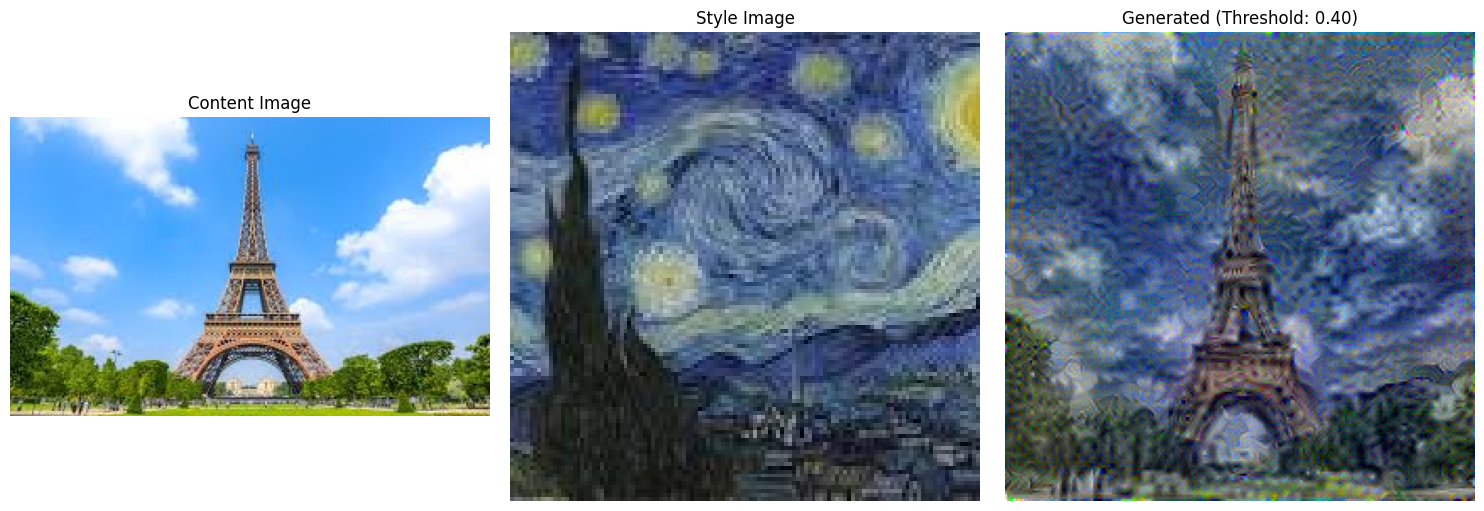

In [ ]:
from google.colab import files
import io
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Helper: Upload one image
def upload_image(prompt="Upload an image"):
    print(prompt)
    uploaded = files.upload()
    file_name = next(iter(uploaded))
    image = Image.open(io.BytesIO(uploaded[file_name])).convert("RGB")
    print(f"Loaded image: {file_name} with size {image.size}")
    return image

# Upload one content and one style image
content_img = upload_image("Upload Content Image")
style_img = upload_image("Upload Style Image")
threshold = 0.4  # You can adjust this manually
NUM_OF_PICS_SHOWN = 1

# Create subplot
fig, axs = plt.subplots(NUM_OF_PICS_SHOWN, 3, figsize=(15, 5 * NUM_OF_PICS_SHOWN))
axs = np.array([axs])  # Ensure it's indexable

for idx in range(NUM_OF_PICS_SHOWN):
    try:
        # Resize content
        if isinstance(content_img, Image.Image):
            content_img.thumbnail((512, 512), Image.LANCZOS)
            width, height = content_img.size
        else:
            height, width = content_img.shape[:2]
            if max(height, width) > 512:
                scale = 512 / max(height, width)
                new_h, new_w = int(height * scale), int(width * scale)
                pil_img = Image.fromarray(np.uint8(content_img))
                pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
                content_img = np.array(pil_img)
                height, width = content_img.shape[:2]

        # Resize style
        if isinstance(style_img, Image.Image):
            style_img.thumbnail((512, 512), Image.LANCZOS)
        else:
            height_s, width_s = style_img.shape[:2]
            if max(height_s, width_s) > 512:
                scale = 512 / max(height_s, width_s)
                new_h, new_w = int(height_s * scale), int(width_s * scale)
                pil_img = Image.fromarray(np.uint8(style_img))
                pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
                style_img = np.array(pil_img)

        # Define size for style transfer
        new_height = RESIZE_HEIGHT
        new_width = RESIZE_HEIGHT

        print(f"Processing image - Size: {new_width}x{new_height}, Threshold: {threshold:.2f}")

        # Run style transfer
        generated_result = style_transfer(
            content_img,
            style_img,
            threshold,
            result_height=new_height,
            result_width=new_width,
            num_iterations=NUM_ITER
        )

        # Prepare for plotting
        if isinstance(content_img, Image.Image):
            content_np = np.array(content_img)
        else:
            content_np = content_img

        if isinstance(style_img, Image.Image):
            style_np = np.array(style_img)
        else:
            style_np = style_img

        axs[idx, 0].imshow(content_np)
        axs[idx, 0].set_title("Content Image")
        axs[idx, 0].axis('off')

        axs[idx, 1].imshow(style_np)
        axs[idx, 1].set_title("Style Image")
        axs[idx, 1].axis('off')

        axs[idx, 2].imshow(generated_result)
        axs[idx, 2].set_title(f"Generated (Threshold: {threshold:.2f})")
        axs[idx, 2].axis('off')

    except Exception as e:
        print(f"Error: {e}")
        for j in range(3):
            axs[idx, j].text(0.5, 0.5, 'Processing failed',
                             ha='center', va='center')
            axs[idx, j].axis('off')

plt.tight_layout()
plt.show()
